# Evolutionary Factor Researcher — a **live** mini-run

The companion notebook `evolutionary_factor_researcher_walkthrough.ipynb` dissects
every part on a *synthetic* panel with the LLM calls switched **off**, so it stays
free and deterministic.  This notebook is the opposite: a **tiny end-to-end run of
the real machine** so you (and a supervisor) can watch it actually turn —

* **real LLM calls** — brainstorm → codegen → reflection → mutation, all against
  the live model (`gpt-4o-mini` by default), and
* **real ML fitting** — every candidate is scored by the deterministic
  `research_eval` harness, which fits a **Ridge** model that combines the book's
  factor signals into one forward-return forecast and measures the candidate's
  **marginal out-of-sample IC** (LOCO), CPCV robustness, deflation, and the hard
  gates,

on a small slice of **real S&P-100 daily data** (served offline from the local
`yfinance` parquet cache — no network needed for the data).

> **The one invariant of the whole design:** the LLM *mutates*, the deterministic
> harness *scores*.  No LLM output ever reaches the reward channel except as code
> to compile — so the model can never influence its own fitness.

This run makes a couple dozen cheap API calls and takes a few minutes.

## 0 · Setup — keys, data cache, run knobs

In [1]:
import os, sys, json, time, textwrap, logging
from pathlib import Path

# --- locate the repo root (the dir that contains quant_fund_agent/) ---
here = Path.cwd()
ROOT = next((p for p in [here, *here.parents] if (p / "quant_fund_agent").is_dir()), None)
assert ROOT is not None, "run this from inside the QuantFundAgent repo"
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

# --- load the OpenAI key from the repo's .env by EXPLICIT path ---
# (load_dotenv() with no arg resolves relative to *this file's* dir, which for a
#  notebook is notebooks/ — so we point it straight at the repo-root .env.)
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

# --- run in-process (identical maths to the MCP server) + free embeddings ---
os.environ["QF_USE_MCP"]     = "0"      # evaluate candidates in-process
os.environ["QF_EMBEDDER"]    = "hash"   # no embedding API needed (RAG is off here)
os.environ["QF_FUNDAMENTALS"] = "0"     # OHLCV-only → fast, fully offline data

# --- surface the evolution loop's own logging inside the notebook ---
logging.basicConfig(level=logging.INFO, format="%(name)-18s %(message)s", stream=sys.stdout)
for noisy in ("httpx", "openai", "urllib3", "httpcore"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

from quant_fund_agent.llm import resolve_research_model
MODEL = resolve_research_model()
has_key = bool(os.getenv("OPENAI_API_KEY"))

# cached tickers available offline
cache = ROOT / "data/market/yfinance/equity/1d"
n_cached = len(list(cache.glob("*.parquet"))) if cache.exists() else 0

print("repo root      :", ROOT)
print("OPENAI_API_KEY :", "present ✅" if has_key else "MISSING ❌ (LLM cells will fail)")
print("research model :", MODEL)
print("cached tickers :", n_cached, "(offline yfinance daily bars)")

repo root      : /Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent
OPENAI_API_KEY : present ✅
research model : gpt-4o-mini
cached tickers : 102 (offline yfinance daily bars)


The knobs below keep this run **small on purpose**.  The exact same objects, scaled
up, are what `run_factor_evolution.py` drives for a thesis run.

In [2]:
N_TICKERS   = 8     # universe slice (first 8 S&P-100 names in the cache)
FIELDS      = ["open", "high", "low", "close", "volume"]
HORIZON     = 6     # forecast/IC horizon in bars (daily → ~6 trading days)
DATA_DIR    = "ticker_data"   # ignored for yfinance (cache is keyed by config), kept for the API
SEED        = 7

# a scratch dir for this run's checkpoints, OUTSIDE the repo (nothing is written
# into data/workspaces/ and nothing clutters the git tree)
import tempfile
SCRATCH = Path(tempfile.gettempdir()) / "qfa_live_demo_evolution"
SCRATCH.mkdir(parents=True, exist_ok=True)
print("scratch out_dir:", SCRATCH)

scratch out_dir: /var/folders/0b/tfp69kqx3697_bkgxskvksmr0000gn/T/qfa_live_demo_evolution


## 1 · The real data panel

Everything downstream reads this one dict of `field -> DataFrame(index=dates,
columns=tickers)`.  It is loaded through the project's data layer, which resolves
the active `quant.config.yaml` (a `yfinance` S&P-100 config) and serves the bars
straight from the parquet cache.

In [3]:
from quant_fund_agent.data import load_panel

panel = load_panel(DATA_DIR, fields=FIELDS, n_tickers=N_TICKERS)
close = panel["close"]
print("fields loaded :", sorted(panel))
print("close panel   :", close.shape, "= (bars, tickers)")
print("tickers       :", list(close.columns))
print("date range    :", close.index.min().date(), "→", close.index.max().date())
close.tail(3)

fields loaded : ['close', 'high', 'low', 'open', 'volume']
close panel   : (1625, 8) = (bars, tickers)
tickers       : ['AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'AIG', 'AMD', 'AMGN']
date range    : 2020-01-02 → 2026-06-22


,AAPL,ABBV,ABT,ACN,ADBE,AIG,AMD,AMGN
Date,,,,,,,,
2026-06-17,295.950012,221.229996,88.500000,156.009995,196.279999,74.769997,512.479980,341.660004
2026-06-18,298.010010,216.490005,88.410004,127.980003,195.160004,74.019997,537.369995,337.600006
2026-06-22,297.010010,230.009995,87.830002,124.830002,194.899994,76.370003,551.630005,344.720001


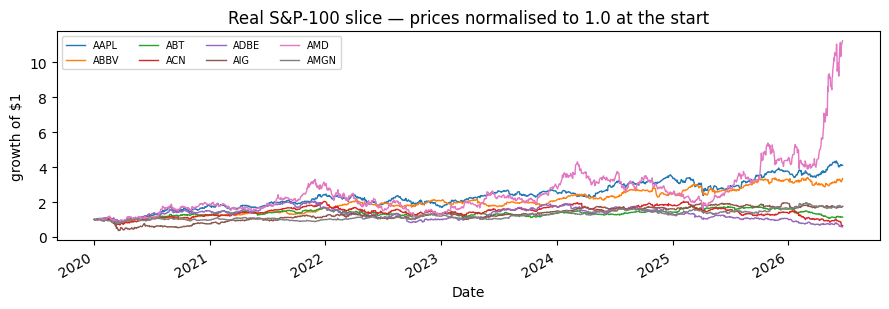

In [4]:
# a quick look at the raw material: normalised price paths for the slice
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(9, 3.2))
(close / close.iloc[0]).plot(ax=ax, lw=1)
ax.set_title("Real S&P-100 slice — prices normalised to 1.0 at the start")
ax.set_ylabel("growth of $1"); ax.legend(ncol=4, fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

## 2 · The data contract the LLM is given

Before any brainstorming, the researcher builds a **data context** — the exact
menu of fields the model is allowed to touch (anything off-menu makes a factor
*out-of-scope* and it is dropped).  It also carries a bar-size-aware **horizon
contract** so the model picks a sensible `prediction_horizon`.  This is the same
`build_data_context` the production pipeline uses.

In [5]:
from quant_fund_agent.agents.factor_research.prompts import build_data_context

# infer seconds-per-bar straight from the real panel index (daily ≈ 86400 s)
_dt = close.index.to_series().diff().dropna().dt.total_seconds()
seconds_per_bar = float(_dt.median()) if len(_dt) else None

DATA_CONTEXT = build_data_context(sorted(FIELDS), seconds_per_bar)
print(f"(inferred seconds/bar = {seconds_per_bar:,.0f}  →  ~{seconds_per_bar/86400:.0f} day bars)\n")
print(DATA_CONTEXT)

(inferred seconds/bar = 86,400  →  ~1 day bars)

You are working with the configured market-data feed (daily bars).  When you write a factor, the ``data``
dict passed to ``calc`` exposes the fields below as ``pd.DataFrame``
(index = bar timestamps, columns = tickers).  Every field below is
available — pick whichever ones your idea actually needs; do NOT use any
field that is not listed (the factor would be rejected as out-of-scope).

Price / OHLCV view:

    open      : start-of-bar price (mid-price on LOBSTER)
    high      : intra-bar high (max(mid, midEnd) on LOBSTER)
    low       : intra-bar low (min(mid, midEnd) on LOBSTER)
    close     : end-of-bar price (mid-price on LOBSTER)
    volume    : traded volume in the bar (|signed trade| on LOBSTER)

Notes:
- All fields are aligned on the same DatetimeIndex and the same ticker
  columns, so cross-field arithmetic is safe.
- Do NOT pass extra keyword arguments to the helper operators below —
  they take positional arguments only.

PR

## 3 · Seeding, step 1 — **brainstorm** (live LLM)

Generation 0 comes from the *same* brainstorm/codegen path the one-shot baseline
uses, so both arms start from the same generator.  Here we call the real model to
propose a few factor **ideas** — each a structured hypothesis: a mechanism, an
`expected_sign`, and a chosen `prediction_horizon`.  Nothing is scored yet.

In [6]:
from quant_fund_agent.agents.factor_research.graph import _brainstorm_one
from quant_fund_agent.llm import make_chat_llm

brainstorm_llm = make_chat_llm(temperature=0.7, timeout=120, max_retries=3)

t0 = time.time()
raw_ideas = _brainstorm_one(brainstorm_llm, paper=None, n_ideas=3,
                            known_ids=set(), session_id="live-demo",
                            data_context=DATA_CONTEXT)
print(f"brainstorm returned {len(raw_ideas)} idea(s) in {time.time()-t0:.1f}s\n")

for i, idea in enumerate(raw_ideas):
    print(f"── idea {i} ─────────────────────────────────────────────")
    print(f"  factor_id  : {idea.get('factor_id')}")
    print(f"  name       : {idea.get('name')}")
    print(f"  category   : {idea.get('category')}")
    print(f"  horizon    : {idea.get('prediction_horizon')}  "
          f"(suggested {idea.get('suggested_horizons')})")
    print(f"  exp. sign  : {idea.get('expected_sign')}")
    print("  idea       :", textwrap.fill(idea.get('trading_idea',''), 92,
                                          subsequent_indent=' '*15))
    print()

factor_research    [session live-demo] brainstorm call (own-knowledge, asked 3, 918 tok): 9.4s


brainstorm returned 3 idea(s) in 9.4s

── idea 0 ─────────────────────────────────────────────
  factor_id  : momentum_price_change_ratio
  name       : Momentum Price Change Ratio
  category   : momentum
  horizon    : 10  (suggested [5, 15, 30])
  exp. sign  : None
  idea       : This factor leverages the momentum effect, which suggests that assets with higher recent
               returns will continue to perform well in the near term. By analyzing the
               ratio of price change over a defined period to the average price change, we
               can capture relative strength and identify potential continuation patterns.

── idea 1 ─────────────────────────────────────────────
  factor_id  : mean_reversion_volume_spike
  name       : Mean Reversion Volume Spike
  category   : mean_reversion
  horizon    : 7  (suggested [3, 14, 21])
  exp. sign  : None
  idea       : In markets, extreme movements in trading volume can indicate overreaction, leading to a
               poten

## 4 · Seeding, step 2 — **codegen** (live LLM)

Each surviving idea is handed to a lower-temperature model that writes an actual
`BaseFactor` subclass.  The code is compiled **in-memory** and smoke-tested (a
candidate only becomes a file if it survives evolution).  If compilation fails, the
error is fed back for **one self-correcting retry** — the same loop the production
codegen uses.

In [7]:
from quant_fund_agent.agents.factor_research.evolution.loop import _codegen_program, coerce_idea

codegen_llm = make_chat_llm(temperature=0.2, timeout=120, max_retries=3)

seed_prog = None
for raw in raw_ideas:
    idea = coerce_idea(raw, HORIZON)
    prog = _codegen_program(codegen_llm, idea, DATA_CONTEXT)   # compiles in-memory
    if prog is not None:
        seed_prog = prog
        break

assert seed_prog is not None, "codegen failed for all ideas (rare — re-run)"
print("compiled factor :", seed_prog.factor_id, "| horizon", seed_prog.prediction_horizon,
      "| expected_sign", seed_prog.expected_sign)
print("=" * 92)
print(seed_prog.code)

compiled factor : momentum_price_change_ratio | horizon 10 | expected_sign None
"""This factor leverages the momentum effect, which suggests that assets with higher recent returns will continue to perform well in the near term. By analyzing the ratio of price change over a defined period to the average price change, we can capture relative strength and identify potential continuation patterns."""

from __future__ import annotations

import pandas as pd
import numpy as np

from quant_fund_agent.factors.base import BaseFactor
from quant_fund_agent.factors.ops import delta, ts_mean, ts_sum, rank
from quant_fund_agent.factors.registry import register_factor


@register_factor
class MomentumPriceChangeRatio(BaseFactor):
    factor_id = "momentum_price_change_ratio"
    name = "Momentum Price Change Ratio"
    category = "momentum"
    description = "The signal computes the ratio of the price change over the last N days to the average daily price change over the same period for each asset, h

## 5 · The reward channel — **real ML fitting** (no LLM)

Now the deterministic part.  `evaluate_fitness` compiles the candidate, computes
its signal on the panel, and scores it on a **5-axis Pareto vector**.  The primary
axis is **marginal value (LOCO)**: a **gradient-boosting** model is fit on the
in-sample window to combine the current book's signals into one forward-return
forecast, and we measure how much the candidate *adds* to the combined model's
**out-of-sample IC**.  The combiner is **nonlinear on purpose** — a linear model
sees only *additive* combination value, so a *conditioning/state* factor (the
classic low-standalone-IC volatility factor, valuable only via `vol × momentum`
interactions) would score ~0; a tree ensemble captures the interaction, so it
scores a **positive** marginal value (`--marginal-model ridge` reproduces the
additive-only behaviour for an ablation).  Around this axis sit four more —

- **independence** = the candidate's **residual (orthogonalised) IC** (its edge in
  the direction the book doesn't already span; the un-saturating replacement for
  the old Δ-participation-ratio),
- **robustness** (CPCV mean − λ·std, − plateau, + sign bonus),
- **parsimony** (−AST complexity), and
- **regime_independence** = its marginal ΔIC **on the crash/stress bars** — edge
  added exactly where the book is weakest, so a crash specialist survives selection
  even with a weaker overall marginal value —

behind hard **gates** (coverage / degradation / deflation) a factor must clear.

The candidate here is scored against an **empty book**, so its marginal value (and
residual IC) reduce to its own standalone combined-model OOS IC, and the regime
axis to its own crash-period IC.

In [8]:
from quant_fund_agent.mcp import research_client

t0 = time.time()
res = research_client.evaluate_fitness(
    candidate={"factor_id": seed_prog.factor_id, "code": seed_prog.code,
               "expected_sign": seed_prog.expected_sign},
    book=[],                       # empty book → marginal value == standalone
    jitter=[],                     # (the plateau probe rides along here in a real run)
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2, n_trials=1,
    cpcv_groups=4, cpcv_k=2, embargo=0,
    data_dir=DATA_DIR, n_tickers=N_TICKERS, fields=FIELDS,
    # new fitness knobs (defaults shown): nonlinear LOCO combiner (captures
    # conditioning value), residual-IC independence, drawdown regime axis
    marginal_model="gradient_boosting",
    independence_metric="residual_ic", regime_kind="drawdown", regime_quantile=0.2,
)
print(f"scored in {time.time()-t0:.1f}s  |  ok = {res['ok']}\n")

fit = res["fitness"]; obj = fit["objective"]; d = fit["diagnostics"]

def _ax(v, nd=4):
    return f"{v:+.{nd}f}" if v is not None else "n/a"

print("── Pareto objective vector (5 axes, all maximised) ─")
print(f"  marginal_value (LOCO ΔOOS-IC, primary) : {_ax(obj['marginal_value'])}")
print(f"  independence   (residual/orthogonal IC): {_ax(obj['independence'])}")
print(f"  robustness     (CPCV mean−λ·std, …)    : {_ax(obj['robustness'])}")
print(f"  parsimony      (−AST complexity)       : {_ax(obj['parsimony'], 1)}")
print(f"  regime_indep.  (ΔIC on crash bars)     : {_ax(obj['regime_independence'])}"
      f"   (stress bars scored: {d.get('n_stress_obs')})")
print("\n── hard gates ──────────────────────────────────────")
g = fit["gates"]
print(f"  passed = {g['passed']}   "
      f"(coverage={g['coverage_ok']}, degradation={g['degradation_ok']}, "
      f"deflation={g['deflation_ok']})")
if g.get("reasons"):
    for k, v in g["reasons"].items():
        print(f"    ✗ {k}: {v}")

research.service   Loading panel from ticker_data (fields=['close', 'high', 'low', 'open', 'volume'], n_tickers=8) …


research.service   Panel loaded in 0.0s (8 tickers, 5 fields)


scored in 1.5s  |  ok = True

── Pareto objective vector (5 axes, all maximised) ─
  marginal_value (LOCO ΔOOS-IC, primary) : +0.0067
  independence   (residual/orthogonal IC): +0.0086
  robustness     (CPCV mean−λ·std, …)    : +0.0018
  parsimony      (−AST complexity)       : -14.0
  regime_indep.  (ΔIC on crash bars)     : -0.0071   (stress bars scored: 376)

── hard gates ──────────────────────────────────────
  passed = True   (coverage=True, degradation=True, deflation=True)


It is completely normal for a first random idea to **fail a gate** (a degradation
gate fires when the edge does not survive out-of-sample).  A failing candidate is
not thrown away silently — its diagnostics become the *teacher signal* for the next
step.

## 6 · Reflection — the deterministic **teacher** (no LLM writes it)

The numeric dashboard is turned into a natural-language **mutation brief** by
rule-based logic — *no LLM writes this*.  Every advice line is triggered by a
threshold on the numbers above.  This brief is the only feedback the mutating LLM
receives about how its parent performed.

In [9]:
from quant_fund_agent.research_eval.fitness import FitnessResult
from quant_fund_agent.agents.factor_research.evolution.reflection import mutation_brief

fitness = FitnessResult.from_dict(fit)
brief = mutation_brief(fitness, book_size=0)
print(brief)

VERDICT: passed every hard gate; competing on the Pareto front.
Marginal value (primary axis): adding this factor moved the combined model's OOS IC by +0.0067 (with=+0.0067, book-only=+0.0000, book size=0).
Standalone IC at the target horizon: +0.0086 (IS=+0.0086, VAL=+0.0086).
IC decay across horizons: 1b=+0.0081, 3b=+0.0218, 6b=+0.0086, 12b=+0.0161, 24b=-0.0106.  |IC| peaks at 3 bars (+0.0218).
Independence (axis = residual_ic): residual IC after regressing out the book +0.0086 — the edge the book does NOT already span; Δ participation ratio +1.0000 (book effective factors +0.00 → +1.00); max |corr| to an existing factor: +0.0000.
Robustness: CPCV IC mean +0.0094 ± +0.0075 over 6 purged folds; OOS/IS degradation ratio +0.9969.
Regime (crash-complementarity): marginal ΔIC on the drawdown stress bars -0.0071 (book-with=-0.0071, book-only=+0.0000, n_stress=376) — edge added exactly where the book is weakest.
Complexity (operators + constants): 14.
Multiple-testing deflation: after 1 tri

## 7 · Mutation — the creative operator (live LLM)

The parent program **plus its reflection brief** are handed back to the LLM, which
proposes a *child* — a genuinely new factor that tries to fix what the brief
flagged.  The child is parsed, its id de-collided, and compiled in-memory (with the
same one-shot feedback retry).  Below we show the parent → child jump.

In [10]:
from quant_fund_agent.agents.factor_research.evolution.mutation import (
    build_mutation_prompt, parse_child_response,
)
from quant_fund_agent.factors.inmem import compile_factor

prompt = build_mutation_prompt(seed_prog, brief, DATA_CONTEXT, existing_ids=[seed_prog.factor_id])

# what the model actually receives (trimmed) — note the brief is embedded verbatim
print("MUTATION PROMPT (excerpt) ".ljust(92, "─"))
print("…parent idea + code + the reflection brief + a strict JSON schema…\n")
print("brief handed to the model:\n" + textwrap.indent(brief.split(chr(10))[0], "    "), "…\n")

resp = brainstorm_llm.invoke(prompt)
child = parse_child_response(getattr(resp, "content", str(resp)))
compile_factor(child.code, child.factor_id, smoke=True)   # validate the child

print("PARENT →", seed_prog.factor_id)
print("  idea :", textwrap.fill(seed_prog.trading_idea or seed_prog.description, 88,
                                subsequent_indent=' '*9))
print("\nCHILD  →", child.factor_id, f"(horizon {child.prediction_horizon}, sign {child.expected_sign})")
print("  idea :", textwrap.fill(child.trading_idea or child.description, 88,
                                subsequent_indent=' '*9))
print("\nchild code:\n" + "=" * 92)
print(child.code)

MUTATION PROMPT (excerpt) ──────────────────────────────────────────────────────────────────
…parent idea + code + the reflection brief + a strict JSON schema…

brief handed to the model:
    VERDICT: passed every hard gate; competing on the Pareto front. …



PARENT → momentum_price_change_ratio
  idea : This factor leverages the momentum effect, which suggests that assets with higher recent
         returns will continue to perform well in the near term. By analyzing the ratio
         of price change over a defined period to the average price change, we can
         capture relative strength and identify potential continuation patterns.

CHILD  → momentum_price_change_ratio_conditioned (horizon 3, sign 1)
  idea : This factor builds on the momentum effect but conditions the price change ratio on
         recent volume spikes. High trading volumes often indicate strong market
         sentiment, which can amplify momentum effects. By focusing on price changes
         during these high-volume periods, the factor seeks to enhance the reliability
         of momentum signals.

child code:
"""This factor builds on the momentum effect but conditions the price change ratio on recent volume spikes. High trading volumes often indicate strong mark

## 8 · The whole loop, turning on its own

Sections 3–7 walked one candidate through one lap by hand.  `EvolutionLoop` does
exactly that in a cycle: **seed → (select parent by NSGA-II tournament → mutate /
crossover / jitter → score → insert → reflect)\***, keeping a gate-passing **Pareto
archive** that *is* the accepted book, with per-generation checkpoints.

We run a deliberately tiny configuration (2 generations, a handful of children).
Watch the log: you will see the real brainstorm, the codegen, each candidate being
scored, and the archive / `n_trials` growing.  `n_trials` is the deflation counter —
every *scored* look is billed so the statistics stay honest.

In [11]:
from quant_fund_agent.agents.factor_research.evolution.loop import (
    EvolutionLoop, EvolutionRunConfig,
)

cfg = EvolutionRunConfig(
    generations=2, population_size=6, children_per_generation=2,
    n_seed_ideas=3, seed_papers=0, retrieval="none",
    p_llm_semantic=0.6, p_crossover=0.2, p_jitter=0.2,
    target_horizon=HORIZON, is_frac=0.6, val_frac=0.2,
    cpcv_groups=4, cpcv_k=2, embargo=0,
    data_dir=DATA_DIR, n_tickers=N_TICKERS, seed=SEED,
    out_dir=str(SCRATCH),
)

# pass the real fields + our correct daily data-context so the loop is consistent
loop = EvolutionLoop(cfg, data_context=DATA_CONTEXT, fields=FIELDS)

t0 = time.time()
summary = loop.run()          # ← real LLM + real ML, generation by generation
print(f"\n{'='*70}\nfinished in {time.time()-t0:.0f}s")
print(json.dumps({k: summary[k] for k in
                  ('generations','n_trials','population','n_eval_failures','elapsed_sec')},
                 indent=2))

factor_research    [session evo-seed-7] brainstorm call (own-knowledge, asked 3, 2863 tok): 7.0s


evolution.loop     seeded 3/3 program(s) from 3 idea(s)


evolution.loop     generation 0: population=3, archive=1, n_trials=3


evolution.loop     generation 1: 2/2 children admitted; archive=1; n_trials=5


evolution.loop     child attempt failed (Expecting ',' delimiter: line 10 column 13 (char 769)) — retrying with feedback


evolution.loop     generation 2: 2/2 children admitted; archive=1; n_trials=7



finished in 73s
{
  "generations": 2,
  "n_trials": 7,
  "population": 6,
  "n_eval_failures": 0,
  "elapsed_sec": 73.0
}


## 9 · Results — the Pareto archive (the accepted book)

The archive is the set of gate-passing genomes on the Pareto front: what the run
would hand downstream.  Each row is a real, compiled factor with a real fitted-model
score.

In [12]:
import pandas as pd, numpy as np

def _r(x, nd):                          # round, but tolerate a None axis
    return round(x, nd) if x is not None else np.nan

rows = []
for eg in loop.controller.archive:
    o = eg.fitness.objective
    rows.append({
        "factor_id": eg.genome.factor_ids[0],
        "gen": eg.genome.generation,
        "operator": eg.genome.operator,
        "marginal_value": _r(o.marginal_value, 4),
        "independence": _r(o.independence, 4),       # residual IC
        "robustness": _r(o.robustness, 4),
        "parsimony": _r(o.parsimony, 1),
        "regime_indep": _r(o.regime_independence, 4),  # crash-complementarity
        "gate_pass": eg.fitness.gates.passed,
    })
archive_df = pd.DataFrame(rows)
if not archive_df.empty:
    archive_df = archive_df.sort_values("marginal_value", ascending=False).reset_index(drop=True)

print(f"archive (Pareto front): {len(archive_df)}   |   "
      f"kept_pool (every gate-passer): {len(loop.controller.kept_pool)}   |   "
      f"n_trials billed: {loop.controller.n_trials}")
print("(with --curation greedy|elastic_net the persisted book is curated from the "
      "kept_pool, not limited to the archive front)")
archive_df

archive (Pareto front): 1   |   kept_pool (every gate-passer): 1   |   n_trials billed: 7
(with --curation greedy|elastic_net the persisted book is curated from the kept_pool, not limited to the archive front)


,factor_id,gen,operator,marginal_value,independence,robustness,parsimony,regime_indep,gate_pass
0,intra_day_volume_surge,0,seed,0.0291,-0.0127,-0.011,-13.0,0.0416,True


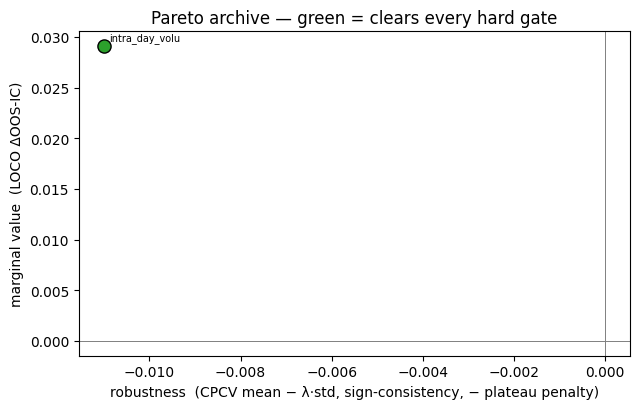

In [13]:
# the two axes the search trades off: marginal OOS edge vs robustness
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for _, r in archive_df.dropna(subset=["robustness", "marginal_value"]).iterrows():
    ax.scatter(r.robustness, r.marginal_value,
               s=90, c=("tab:green" if r.gate_pass else "tab:red"),
               edgecolor="k", zorder=3)
    ax.annotate(r.factor_id[:14], (r.robustness, r.marginal_value),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axhline(0, color="grey", lw=.7); ax.axvline(0, color="grey", lw=.7)
ax.set_xlabel("robustness  (CPCV mean − λ·std, sign-consistency, − plateau penalty)")
ax.set_ylabel("marginal value  (LOCO ΔOOS-IC)")
ax.set_title("Pareto archive — green = clears every hard gate")
plt.tight_layout(); plt.show()

In [14]:
# lineage: who each survivor descends from (the last few admitted genomes)
print("lineage tail (genome ← operator ← parents):")
for row in loop.controller.lineage[-6:]:
    print(f"  gen{row.get('generation')}  {row.get('operator'):11}  "
          f"{row.get('genome_id')}  ← {row.get('parent_ids') or '(seed)'}")

lineage tail (genome ← operator ← parents):
  gen0  seed         g0-price_action_reversal_strength-3789a2  ← (seed)
  gen0  seed         g0-high_low_diff_trend-483461  ← (seed)
  gen1  crossover    g1-high_low_reversal_strength-aba88b  ← ['g0-high_low_diff_trend-483461', 'g0-price_action_reversal_strength-3789a2']
  gen1  crossover    g1-high_low_volume_trend-f72a12  ← ['g0-high_low_diff_trend-483461', 'g0-intra_day_volume_surge-101f1a']
  gen2  llm_semantic  g2-intra_day_volume_anomaly-59e32b  ← ['g0-intra_day_volume_surge-101f1a']
  gen2  llm_semantic  g2-price_action_reversal_strength_enhanced-610627  ← ['g0-price_action_reversal_strength-3789a2']


## 10 · From here to a thesis run

That was the whole machine in miniature, running for real.  Nothing here was
persisted — `persist_archive(...)` is what materialises the final book into
`data/workspaces/<config>/preruns/<name>/`, after which the comparison and
walk-forward harnesses score it exactly like a one-shot prerun.

To scale the *same* objects up (papers, islands, a stronger model, RAG/GraphRAG
grounding, the Hypothesis→Debate→Codegen split, and **two-stage curation**):

```bash
# a real evolution prerun (persisted); keep every gate-passer, curate a 12-factor book
python run_factor_evolution.py --name evo1 --generations 12 --population 12 \
    --children-per-gen 10 --islands 2 --seed-papers 6 --retrieval graphrag \
    --debate on --model gpt-4o --curation greedy --n-keep 12

# then walk-forward validation of the whole loop
python run_factor_evolution.py --name evo1 --walk-forward 2023-01-01,2024-01-01,2025-01-01
```

`--curation archive` (the default) persists the Pareto front (the one-stage
behaviour); `--curation greedy|elastic_net` persists the curated `kept_pool`
instead, so a good factor is not discarded merely for being dominated.  The
independence axis defaults to residual IC (`--independence-metric
delta_participation` restores the legacy Δ-participation-ratio for an ablation),
and the regime axis is configurable via `--regime-kind {drawdown,volatility}`.

For the conceptual deep-dive on each component (splits, deflation, the 5-axis
objective vector, the NSGA-II controller, two-stage curation, RAG/GraphRAG) see the
companion notebook `evolutionary_factor_researcher_walkthrough.ipynb`.